# 02 - Split, Engenharia de Features e Baseline

**O que este notebook faz:** separa treino/teste ANTES de qualquer transformacao (evita vazamento de dados), constroi as features de anomalia (desvio de preco vs. mediana do grupo estado+produto, ajustada so no treino), treina um modelo baseline (IsolationForest) e salva tudo (`referencia`, `preprocessador`, `baseline`) para os proximos notebooks reaproveitarem exatamente o mesmo pipeline.

Continuacao de `01_EDA.ipynb`, cuja conclusao principal foi: preco bruto nao serve como feature de anomalia porque varia demais entre estados e produtos.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import os
import joblib  # serializa preprocessador/modelos para reuso nos proximos notebooks
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

from src.data import carregar_dados
from src.features import ReferenciaPrecos, construir_preprocessador
from src.models import prever_anomalias

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = '../data/precos_combustiveis_anp_2025-12.csv'

df = carregar_dados(CAMINHO_DADOS)
df.shape

(52336, 10)

## 3. Split treino/teste — ANTES de qualquer transformacao

Estratificamos por `produto` para manter a mesma proporcao de gasolina/etanol/gasolina aditivada nos dois conjuntos (na EDA vimos que essa proporcao ja e razoavelmente equilibrada: ~38/32/30%). Nenhuma estatistica (mediana, escala, encoding) e calculada ainda — isso so acontece depois do split, e sempre ajustado (`fit`) apenas no treino, para nao vazar informacao do teste para o treino.

In [3]:
treino, teste = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df['produto']
)
print('Treino:', treino.shape)
print('Teste :', teste.shape)

Treino: (39252, 10)
Teste : (13084, 10)


In [4]:
# Guardamos o split bruto (antes das features) para os proximos notebooks
# reproduzirem exatamente os mesmos conjuntos, sem precisar repetir o
# train_test_split (e arriscar usar outra seed/proporcao por engano).
treino.to_csv('../data/treino.csv', index=False)
teste.to_csv('../data/teste.csv', index=False)

**Resultado:** 39.252 linhas no treino e 13.084 no teste (75/25), com a mesma proporcao de produtos da base completa.

## 4. Engenharia de features

A feature mais informativa para este problema nao e o preco bruto, e sim o **desvio percentual em relacao a mediana do grupo (estado + produto)** — vimos na EDA que o preco 'normal' varia muito por regiao e produto (ex.: mediana da gasolina R$ 5,79 no Piaui vs. R$ 7,39 no Acre). As medianas de referencia sao calculadas com `ReferenciaPrecos.fit(treino)` e so depois aplicadas ao teste (`.transform`), para nao vazar informacao do teste.

In [5]:
referencia = ReferenciaPrecos().fit(treino)

treino_feat = referencia.transform(treino)
teste_feat = referencia.transform(teste)

treino_feat[['valor_venda', 'desvio_pct_estado_produto', 'desvio_pct_brasil_produto']].describe()

,valor_venda,desvio_pct_estado_produto,desvio_pct_brasil_produto
count,39252.000000,39252.000000,39252.000000
mean,5.727162,0.006092,0.004178
std,0.908908,0.056083,0.069500
min,3.490000,-0.207891,-0.222717
25%,4.790000,-0.023866,-0.044543
50%,5.990000,0.000000,0.000000
75%,6.390000,0.033389,0.043818
max,9.590000,0.550918,0.500808


**Resultado:** o desvio percentual fica concentrado perto de zero (mediana 0, desvio-padrao ~5,6% em relacao ao estado e ~7,0% em relacao ao Brasil), com cauda indo ate ~55% acima da mediana — exatamente o tipo de feature com escala comparavel entre estados e produtos que faltava ao usar so o preco bruto.

## 5. Preprocessador (padronizacao + one-hot) — ajustado so no treino

In [6]:
preprocessador = construir_preprocessador()

X_treino = preprocessador.fit_transform(treino_feat)
X_teste = preprocessador.transform(teste_feat)

print('X_treino:', X_treino.shape)
print('X_teste :', X_teste.shape)

X_treino: (39252, 9)
X_teste : (13084, 9)


**Resultado:** 9 colunas na matriz final (3 numericas padronizadas + 6 dummies de `produto`/`regiao` com `drop='first'`) — dimensao pequena o suficiente para todos os 4 modelos do notebook 03 rodarem rapido, inclusive o OneClassSVM.

## 6. Baseline: IsolationForest

### Como o algoritmo funciona

IsolationForest nao aprende "o formato do normal" (como uma gaussiana) — ele tenta **isolar** cada ponto o mais rapido possivel e mede quao facil isso foi. Cada arvore da floresta e construida assim: escolhe uma feature aleatoria, escolhe um valor de corte aleatorio entre o minimo e o maximo dessa feature, e particiona os dados; repete recursivamente ate cada ponto ficar sozinho em uma folha (ou atingir a profundidade maxima).

A intuicao central: um ponto anomalo esta "longe" da massa de dados normais em pelo menos uma dimensao, entao poucos cortes aleatorios ja bastam para isola-lo — ele fica em uma folha **rasa** (perto da raiz). Um ponto normal, cercado por muitos vizinhos parecidos, precisa de muito mais cortes para ser separado de todo mundo — fica em uma folha **profunda**. O `score_amostra` de cada ponto e o comprimento medio do caminho ate isola-lo, calculado sobre as `n_estimators=200` arvores da floresta e normalizado contra o comprimento esperado de uma busca sem sucesso numa arvore binaria balanceada (formula de Liu, Ting & Zhou, 2008): caminho curto -> score alto -> mais anomalo.

Vantagens praticas para este problema: nao exige que `valor_venda`/os desvios sigam distribuicao normal (o que a EDA ja mostrou que nao seguem), e escala bem com `n` (complexidade media O(n log n)), diferente do OneClassSVM que veremos no notebook 03.

### Por que comecar com `contamination=0.02`

`contamination` diz ao modelo "que fracao dos dados de treino devo tratar como anomalia ao decidir o limiar de corte do score". Nao e um numero arbitrario aqui — ele parte direto da triangulacao feita na EDA (`01_EDA.ipynb`, secao 8), onde tres metodos univariados discordaram sobre a taxa exata mas convergiram numa faixa:

| Metodo (EDA) | % marcada como anomalia |
|---|---|
| Z-score classico (media/desvio) | 0,76% |
| Z-score robusto (mediana/MAD) | 1,81% |
| Cercas de Tukey (IQR) | 2,93% |

`contamination=0.02` (2%) fica propositalmente no meio dessa faixa — mais proximo da estimativa robusta (1,81%) que ja sabemos ser mais confiavel que a classica (que sofre do efeito de mascaramento discutido na EDA), mas com uma margem para o lado do Tukey, ja que aqueles metodos so olham `valor_venda` isoladamente por grupo, enquanto o IsolationForest usa varias features ao mesmo tempo e pode revelar mais anomalias multivariadas (ex.: combinacoes de preco + regiao + produto estranhas que nao aparecem como outlier univariado). E, de qualquer forma, uma estimativa inicial: o valor exato so pode ser validado com um rotulo de verdade, que este notebook ainda nao tem — isso e feito no notebook `04_avaliacao_tuning`, testando uma grade de valores de `contamination` contra anomalias sinteticas com rotulo conhecido.

In [7]:
baseline = IsolationForest(contamination=0.02, n_estimators=200, random_state=42)
baseline.fit(X_treino)

rotulo_teste, score_teste = prever_anomalias(baseline, X_teste)
print('Anomalias no teste:', rotulo_teste.sum(), '/', len(rotulo_teste))

Anomalias no teste: 247 / 13084


## 7. Inspecionar as anomalias apontadas pelo baseline

In [8]:
resultado = teste_feat.copy()
resultado['anomalia'] = rotulo_teste
resultado['score_anomalia'] = score_teste

colunas_mostrar = ['estado', 'municipio', 'revenda', 'produto', 'valor_venda',
                   'desvio_pct_estado_produto', 'bandeira', 'score_anomalia']
resultado.sort_values('score_anomalia', ascending=False)[colunas_mostrar].head(15)

,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2654,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
5531,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.185980,BRANCA,0.083033
6088,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
8281,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
3317,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,ATEM' S,0.083033
5869,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.185980,BRANCA,0.083033
9586,SP,BARUERI,FGN COMERCIAL LTDA,GASOLINA ADITIVADA,9.49,0.508744,VIBRA,0.079915
715,SP,BARUERI,CENTRO AUTOMOTIVO ALPHA CENTER LTDA,GASOLINA ADITIVADA,9.49,0.508744,VIBRA,0.079915
12650,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.29,0.476948,VIBRA,0.079915
7846,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA,8.29,0.185980,BRANCA,0.074197


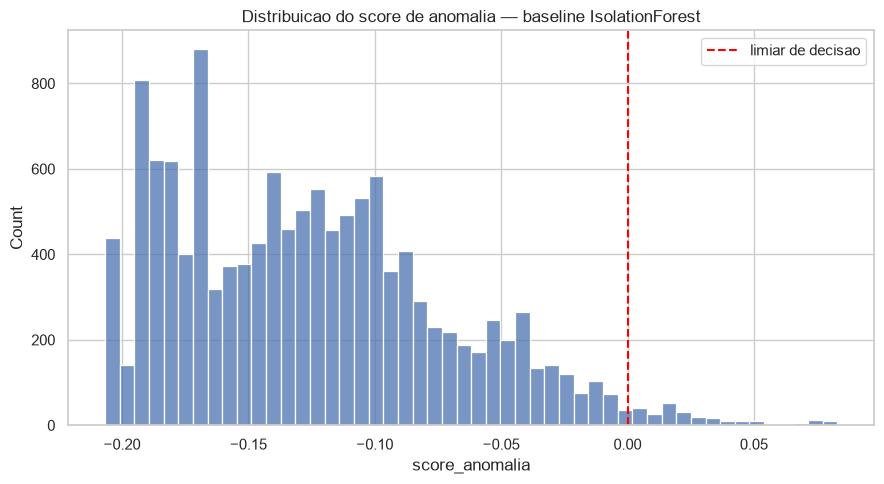

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(resultado['score_anomalia'], bins=50, ax=ax)
ax.axvline(0, color='red', ls='--', label='limiar de decisao')
ax.set_title('Distribuicao do score de anomalia — baseline IsolationForest')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/baseline_distribuicao_score.png', dpi=120)
plt.show()

**Resultado:** o baseline aponta 247 anomalias no teste (~1,9%, proximo do `contamination` configurado). Municipios como Parintins (AM) aparecem repetidas vezes no topo do ranking — sinal de que alguns postos/regioes especificas concentram desvios de preco persistentes, e nao so ruido aleatorio pontual. O histograma do score mostra a maioria dos pontos claramente do lado 'normal' (score negativo) do limiar em zero, com uma cauda curta de scores altos — o padrao esperado para um problema de anomalias raras.

## 8. Salvar preprocessador e modelo baseline

Salvamos `referencia` (medianas) e `preprocessador` junto do modelo porque qualquer dado novo precisa passar pelas MESMAS transformacoes ajustadas no treino antes de ser avaliado.

In [10]:
joblib.dump(referencia, '../models/referencia_precos.joblib')
joblib.dump(preprocessador, '../models/preprocessador.joblib')
joblib.dump(baseline, '../models/baseline_isolation_forest.joblib')
print('Salvo em ../models/')

Salvo em ../models/


## 9. Proximos passos

- `03_modelagem_comparacao.ipynb`: comparar o IsolationForest com LocalOutlierFactor, OneClassSVM e EllipticEnvelope.
- `04_avaliacao_tuning.ipynb`: injetar anomalias sinteticas no teste para medir precision/recall de verdade e ajustar hiperparametros.